# Model alpha and beta parameter estimation

## Estimate Alpha from mono and co-culture

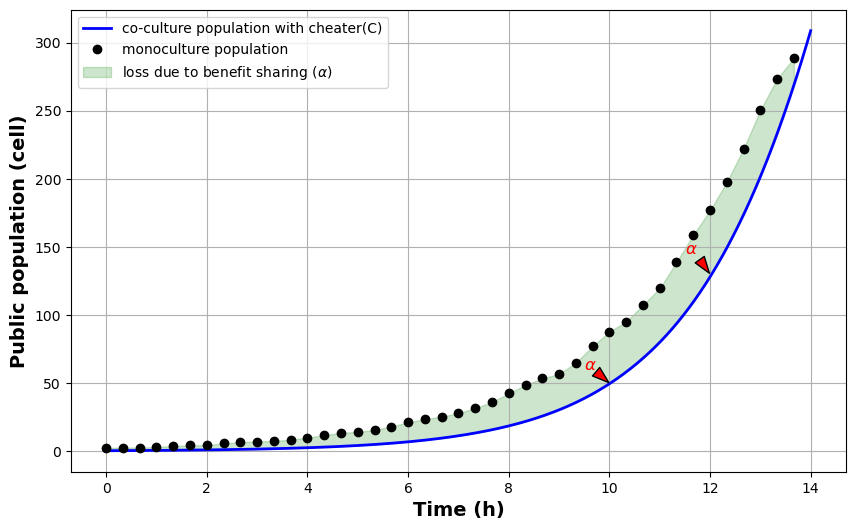

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy.integrate import solve_ivp
from src.parameters import parameters

# Define the System of ODEs
def deriv(t, y, params):
    P, C, M = y
    dP = (params["r_p"] * P
          - params["alpha"] * C * P
          - params["eta"] * P**2)
    dC = (params["alpha"] * C * P
          - params["nu"] * C**2)
    dM = (params["r_m"] * M
          - params["beta"] * P * M
          - params["gamma"] * M**2)
    return [dP, dC, dM]

# Simulation Parameters
T = 14                # Total simulation time
P0, C0, M0 = 1, 1, 1  # Initial populations
initial_conditions = [P0, C0, M0]
time = np.linspace(0, T, 1000)  # Time points for evaluation

# Solve the ODE System
solution = solve_ivp(
    deriv,
    [0, T],
    initial_conditions,
    t_eval=time,
    args=(parameters,),
    method="RK45"
)

# Extract Results
P_sol, C_sol, M_sol = solution.y

# Select the first and last columns from the second file
first_column_3 = df3.iloc[:, 0]  # Time
last_column_3  = df3.iloc[:, -1] # Data to plot

# Find the maximum value in the experimental data
max_value = last_column_3.max()

# Normalize the simulation results by the maximum value of the experimental data
P_sol_normalized = P_sol / P_sol.max() * max_value
C_sol_normalized = C_sol / C_sol.max() * max_value
M_sol_normalized = M_sol / M_sol.max() * max_value

# Convert the experimental columns to numpy for convenience
x_exp = first_column_3.iloc[:42].to_numpy()
y_exp = last_column_3.iloc[:42].to_numpy()

#    This aligns them in time so you can fill between the two curves.
y_sim_at_data_points = np.interp(x_exp, time, P_sol_normalized)

# Plot the Results
plt.figure(figsize=(10, 6))

# (1) Plot the simulation (green line)
plt.plot(time, P_sol_normalized,
         label='co-culture population with cheater(C)',
         color='b', linestyle='-', linewidth=2)

# (2) Plot the Monoculture
plt.plot(x_exp, y_exp,
         label='monoculture population',
         color='black', marker='o', linestyle='None')

# (3) Fill the area between the two curves (green shading)
#     We only fill where we have experimental data (0 to x_exp[-1]).
x_fill = x_exp
y1_fill = y_sim_at_data_points
y2_fill = y_exp

plt.fill_between(x_fill, y1_fill, y2_fill,
                 color='green', alpha=0.2,
                 label='loss due to benefit sharing ($\\alpha$)')

# Add arrows to indicate the effect of alpha
arrow_params = dict(facecolor="red", shrink=0.05, width=2, headwidth=8)
plt.annotate(r"$\alpha$",
             xy=(10, 50), xytext=(9.5, 60),
             arrowprops=arrow_params, fontsize=12, color='red')
plt.annotate(r"$\alpha$",
             xy=(12, 130), xytext=(11.5, 145),
             arrowprops=arrow_params, fontsize=12, color='red')

# Customize plot
plt.xlabel('Time (h)', fontsize=14, fontweight='bold')
plt.ylabel('Public population (cell)', fontsize=14, fontweight='bold')
#plt.title('Comparison of Public Metabolizer in Mono vs. Co-culture', fontsize=14)
plt.legend()
plt.grid(True)

# Save figure
os.makedirs("output/figures", exist_ok=True)
plt.savefig("output/figures/alpha_analysis_shaded.png", dpi=300)

# Show the plot
plt.show()


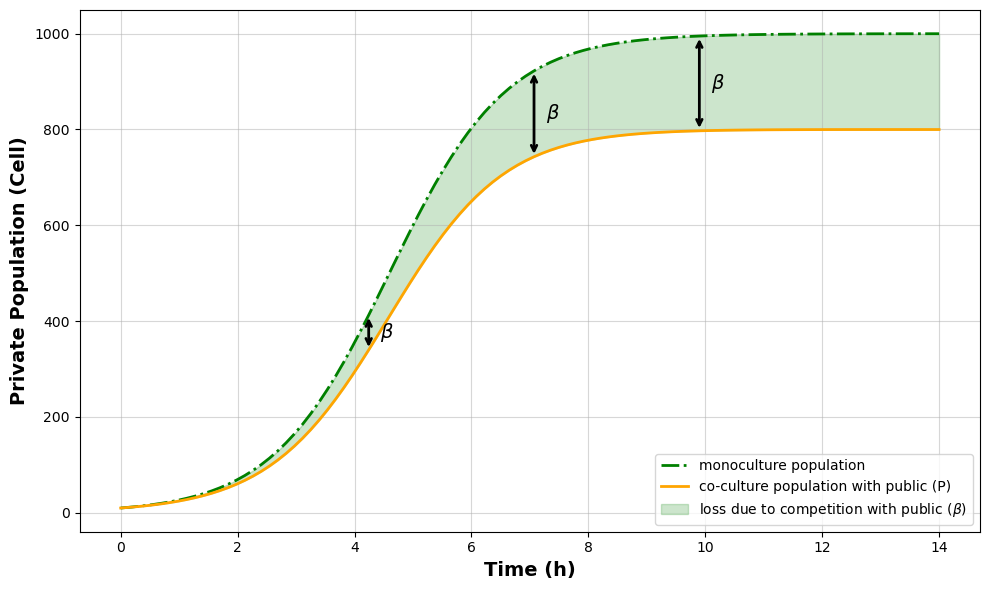

<Figure size 640x480 with 0 Axes>

In [11]:
# Import libraries
import matplotlib.pyplot as plt
import numpy as np
import os
# Time points for simulation
time = np.linspace(0, 14, 100)

# Parameters for population dynamics
r_p = 1.0       # Intrinsic growth rate of public population (P)
lambda_c = 0.1  # Self-limiting term for public population (P)
beta = 0.3      # Competition effect from private population (M)

# Monoculture Dynamics: Public Population (C)
P_mono_pop = 1 / (1 + (1 / 0.01 - 1) * np.exp(-r_p * time))  # Logistic growth model
P_mono_cell_count = C_mono_pop * 1e3  # Directly representing cell count for clarity

# Co-Culture Dynamics: Public Population  with Private Population 
M_effect = beta * (1 - np.exp(-0.5 * time))  # Private population effect (arbitrary function)
P_co_M_pop = P_mono_pop * (1 - 0.2 * P_effect / max(P_effect))  # Adjust public population based on competition
P_co_M_cell_count = P_co_M_pop * 1e3 # Convert to cell count for plotting

# Plot: Effect of Private Population (β) on Public Population
plt.figure(figsize=(10, 6))

# Monoculture Line: Public Population (P)
plt.plot(time, P_mono_cell_count, 
         label='monoculture population', 
         color='green', linestyle='-.', linewidth=2)

# Co-Culture Line: Public Population (P) under competition
plt.plot(time, P_co_M_cell_count, 
         label='co-culture population with public (P)', 
         color='orange', linewidth=2 )

# Highlight the effect of competition with Private Population (β)
plt.fill_between(time, P_mono_cell_count, P_co_M_cell_count, 
                 color='green', alpha=0.2, 
                 label='loss due to competition with public ($\\beta$)')

# Add three double-sided arrows to indicate β at different locations
arrow_properties = dict(arrowstyle="<->", color="black", linewidth=2)

# Position 1: Early phase
idx1 = 30  # Early time index
plt.annotate("", 
             xy=(time[idx1], P_mono_cell_count[idx1]), 
             xytext=(time[idx1], P_co_M_cell_count[idx1]),
             arrowprops=arrow_properties)
plt.text(time[idx1] + 0.2, (P_mono_cell_count[idx1] + P_co_M_cell_count[idx1]) / 2, 
         r"$\beta$", fontsize=14, fontweight='bold', color="black", ha="left", va="center")

# Position 2: Mid phase
idx2 = 50  # Mid time index
plt.annotate("", 
             xy=(time[idx2], P_mono_cell_count[idx2]), 
             xytext=(time[idx2], P_co_M_cell_count[idx2]),
             arrowprops=arrow_properties)
plt.text(time[idx2] + 0.2, (P_mono_cell_count[idx2] + P_co_M_cell_count[idx2]) / 2, 
         r"$\beta$", fontsize=14, fontweight='bold', color="black", ha="left", va="center")

# Position 3: Late phase
idx3 = 70  # Late time index
plt.annotate("", 
             xy=(time[idx3], P_mono_cell_count[idx3]), 
             xytext=(time[idx3], P_co_M_cell_count[idx3]),
             arrowprops=arrow_properties)
plt.text(time[idx3] + 0.2, (P_mono_cell_count[idx3] + P_co_M_cell_count[idx3]) / 2, 
         r"$\beta$", fontsize=14, fontweight='bold', color="black", ha="left", va="center")

# Graph Labels and Legend
plt.xlabel("Time (h)", fontsize=14, fontweight='bold')
plt.ylabel("Private Population (Cell)", fontsize=14, fontweight='bold')
#plt.title("Effect of Competition Parameter ($\\beta$) on Public Population", fontsize=16)
plt.legend(fontsize=10, loc="lower right")
plt.grid(alpha=0.5)

# Layout adjustment and show
plt.tight_layout()
plt.show()
os.makedirs("output/figures", exist_ok=True)
plt.savefig("output/figures/beta analysis.png", dpi=300)
plt.show()